⌛ 1. Veri seti ve modeller yükleniyor...
⚙️ 2. Geçmiş veriler üzerinde ALAZ risk skorları simüle ediliyor...

🔥 ALAZ RİSK SKORU KARŞILAŞTIRMASI


,Yangın Olan Günler (Target=1),Sıradan Günler (Target=0)
count,15435.00,138200.00
mean,19.93,8.04
std,13.01,8.21
min,0.56,0.52
10%,5.52,0.88
25%,9.31,2.18
50%,16.69,5.16
75%,29.22,10.79
90%,39.09,19.66
max,67.44,63.93



🌡️ FWI SKORU KARŞILAŞTIRMASI


,Yangın Olan Günler (Target=1),Sıradan Günler (Target=0)
count,15435.00,138200.00
mean,36.17,24.65
std,15.65,19.21
min,0.00,0.00
10%,7.49,0.03
25%,28.73,1.75
50%,40.77,27.57
75%,47.70,42.19
90%,51.93,49.47
max,63.49,64.64



📊 3. Dağılım Grafikleri Çizdiriliyor...


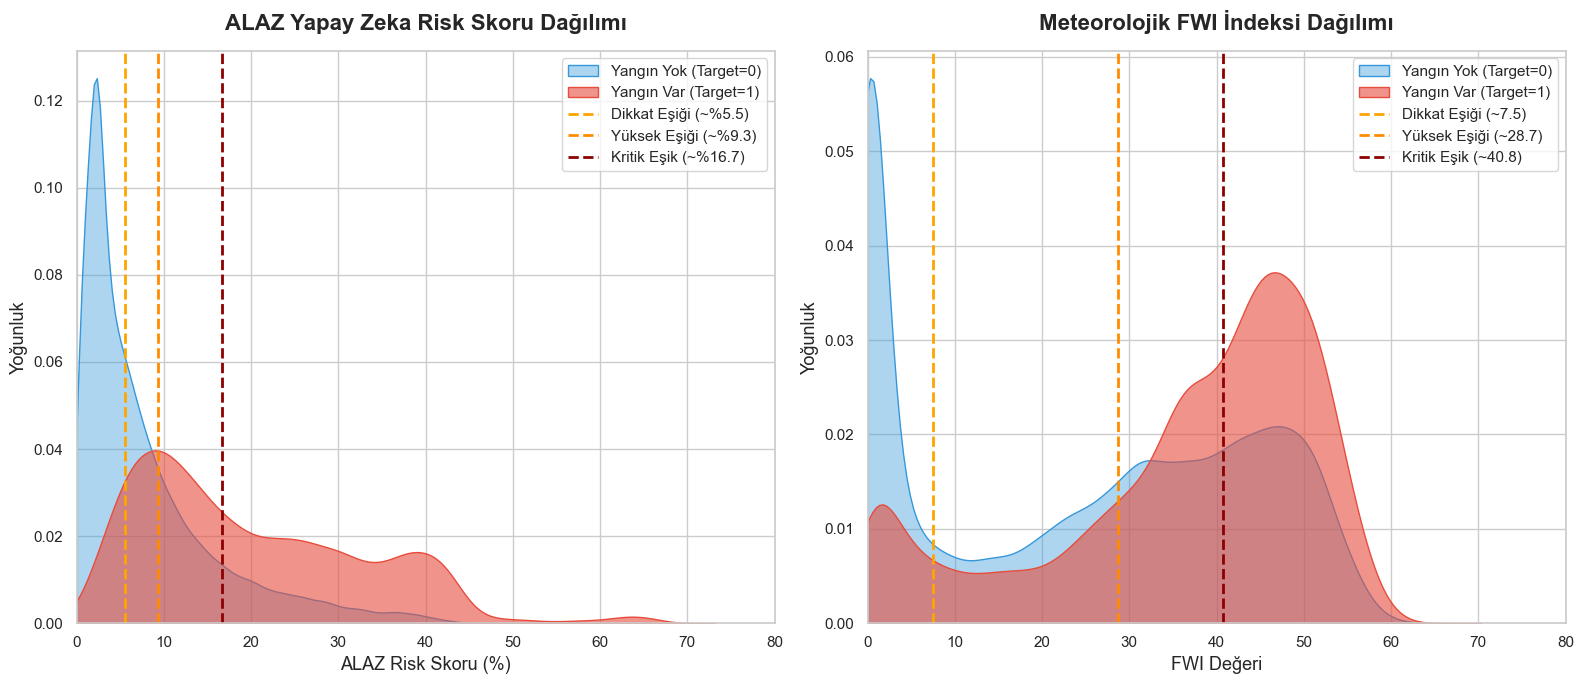

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Görsel ayarları (Hocaya sunum için daha şık görünmesi adına)
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# ----------------- 1. VERİ VE MODEL YÜKLEME -----------------
base_dir = r"c:\Users\Yusuf\Desktop\Tez-bolgesel"

print("⌛ 1. Veri seti ve modeller yükleniyor...")
df = pd.read_parquet(os.path.join(base_dir, "Ara_dosyalar", "M11", "M11_final_dataset.parquet"))
models_dir = os.path.join(base_dir, "Sonuclar", "M13")
models = joblib.load(os.path.join(models_dir, "M13_calibrated_regional_models.joblib"))
features = joblib.load(os.path.join(base_dir, "Sonuclar", "M12", "M12_pruned_feature_sets.joblib"))

# ----------------- 2. ALAZ TAHMİNLERİNİN HESAPLANMASI -----------------
print("⚙️ 2. Geçmiş veriler üzerinde ALAZ risk skorları simüle ediliyor...")
df['risk_percent'] = 0.0

for bolge in ['MED', 'CON', 'BLK']:
    mask = df['Bolge'] == bolge
    if mask.sum() == 0: continue
    
    model = models[bolge]
    feats = features[bolge]
    
    X = df.loc[mask].copy()
    for f in feats:
        if f not in X.columns:
            X[f] = 0
    X = X[feats]
    
    df.loc[mask, 'risk_percent'] = model.predict_proba(X)[:, 1] * 100

# ----------------- 3. HEDEFE GÖRE AYIRMA (YANGIN OLAN/OLMAYAN) -----------------
fires = df[df['Target'] == 1]
non_fires = df[df['Target'] == 0]

# Notebook'ta güzel görünmesi için DataFrame'e çeviriyoruz
alaz_stats = pd.DataFrame({
    'Yangın Olan Günler (Target=1)': fires['risk_percent'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]),
    'Sıradan Günler (Target=0)': non_fires['risk_percent'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
}).round(2)

fwi_stats = pd.DataFrame({
    'Yangın Olan Günler (Target=1)': fires['FWI_Final'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]),
    'Sıradan Günler (Target=0)': non_fires['FWI_Final'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
}).round(2)

print("\n🔥 ALAZ RİSK SKORU KARŞILAŞTIRMASI")
display(alaz_stats)  # Jupyter'de tabloyu güzel basar

print("\n🌡️ FWI SKORU KARŞILAŞTIRMASI")
display(fwi_stats)

# ----------------- 4. DAĞILIM VE EŞİK GÖRSELLEŞTİRMESİ -----------------
print("\n📊 3. Dağılım Grafikleri Çizdiriliyor...")

# Kritik Eşikleri Hesapla (Yangın olan günlerin 25. ve 50. yüzdelik dilimleri)
alaz_dikkat = fires['risk_percent'].quantile(0.10)
alaz_yuksek = fires['risk_percent'].quantile(0.25)
alaz_kritik = fires['risk_percent'].quantile(0.50)

fwi_dikkat = fires['FWI_Final'].quantile(0.10)
fwi_yuksek = fires['FWI_Final'].quantile(0.25)
fwi_kritik = fires['FWI_Final'].quantile(0.50)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ----- ALAZ GRAFİĞİ -----
sns.kdeplot(data=non_fires, x='risk_percent', label='Yangın Yok (Target=0)', fill=True, color='#3498db', alpha=0.4, ax=axes[0])
sns.kdeplot(data=fires, x='risk_percent', label='Yangın Var (Target=1)', fill=True, color='#e74c3c', alpha=0.6, ax=axes[0])

axes[0].axvline(alaz_dikkat, color='orange', linestyle='--', linewidth=2, label=f'Dikkat Eşiği (~%{alaz_dikkat:.1f})')
axes[0].axvline(alaz_yuksek, color='darkorange', linestyle='--', linewidth=2, label=f'Yüksek Eşiği (~%{alaz_yuksek:.1f})')
axes[0].axvline(alaz_kritik, color='darkred', linestyle='--', linewidth=2, label=f'Kritik Eşik (~%{alaz_kritik:.1f})')

axes[0].set_title("ALAZ Yapay Zeka Risk Skoru Dağılımı", fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel("ALAZ Risk Skoru (%)", fontsize=13)
axes[0].set_ylabel("Yoğunluk", fontsize=13)
axes[0].set_xlim(0, 80)
axes[0].legend(fontsize=11, loc='upper right')

# ----- FWI GRAFİĞİ -----
sns.kdeplot(data=non_fires, x='FWI_Final', label='Yangın Yok (Target=0)', fill=True, color='#3498db', alpha=0.4, ax=axes[1])
sns.kdeplot(data=fires, x='FWI_Final', label='Yangın Var (Target=1)', fill=True, color='#e74c3c', alpha=0.6, ax=axes[1])

axes[1].axvline(fwi_dikkat, color='orange', linestyle='--', linewidth=2, label=f'Dikkat Eşiği (~{fwi_dikkat:.1f})')
axes[1].axvline(fwi_yuksek, color='darkorange', linestyle='--', linewidth=2, label=f'Yüksek Eşiği (~{fwi_yuksek:.1f})')
axes[1].axvline(fwi_kritik, color='darkred', linestyle='--', linewidth=2, label=f'Kritik Eşik (~{fwi_kritik:.1f})')

axes[1].set_title("Meteorolojik FWI İndeksi Dağılımı", fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel("FWI Değeri", fontsize=13)
axes[1].set_ylabel("Yoğunluk", fontsize=13)
axes[1].set_xlim(0, 80)
axes[1].legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

🚀 ALAZ Motoru başlatılıyor (Statik veriler yükleniyor)...
[ALAZ] M2 (Topoloji), M3 (Yangın Geçmişi) ve M8 (NDVI) belleğe alınıyor...
📡 2024-07-21 için hava durumu verileri çekiliyor ve ALAZ çalıştırılıyor...
[ALAZ] Makine Öğrenmesi (Sentetik) özellikleri üretiliyor: 2024-07-21


c:\Users\Yusuf\Desktop\Tez-bolgesel\Web_App\backend\inference.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ml['NDVI'].fillna(df_ml['NDVI'].median(), inplace=True)


📡 2024-07-22 için hava durumu verileri çekiliyor ve ALAZ çalıştırılıyor...
[ALAZ] Makine Öğrenmesi (Sentetik) özellikleri üretiliyor: 2024-07-22


c:\Users\Yusuf\Desktop\Tez-bolgesel\Web_App\backend\inference.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ml['NDVI'].fillna(df_ml['NDVI'].median(), inplace=True)


📡 2024-07-23 için hava durumu verileri çekiliyor ve ALAZ çalıştırılıyor...
[ALAZ] Makine Öğrenmesi (Sentetik) özellikleri üretiliyor: 2024-07-23


...

c:\Users\Yusuf\Desktop\Tez-bolgesel\Web_App\backend\inference.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ml['NDVI'].fillna(df_ml['NDVI'].median(), inplace=True)


📡 2024-07-28 için hava durumu verileri çekiliyor ve ALAZ çalıştırılıyor...
[ALAZ] Makine Öğrenmesi (Sentetik) özellikleri üretiliyor: 2024-07-28


c:\Users\Yusuf\Desktop\Tez-bolgesel\Web_App\backend\inference.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ml['NDVI'].fillna(df_ml['NDVI'].median(), inplace=True)



✅ === SİMÜLASYON TAMAMLANDI ===
Toplam incelenen grid-gün sayısı: 1884968

📋 21-28 TEMMUZ RİSK VE FWI DAĞILIMI (TÜM HARİTA)


,ALAZ Risk (%),FWI Skoru
count,1884968.00,1884968.00
mean,3.60,3.66
std,2.11,3.95
min,0.58,0.00
50%,3.22,1.51
75%,4.49,7.06
85%,5.21,8.57
90%,6.16,9.50
95%,8.19,10.75
99%,11.00,13.06


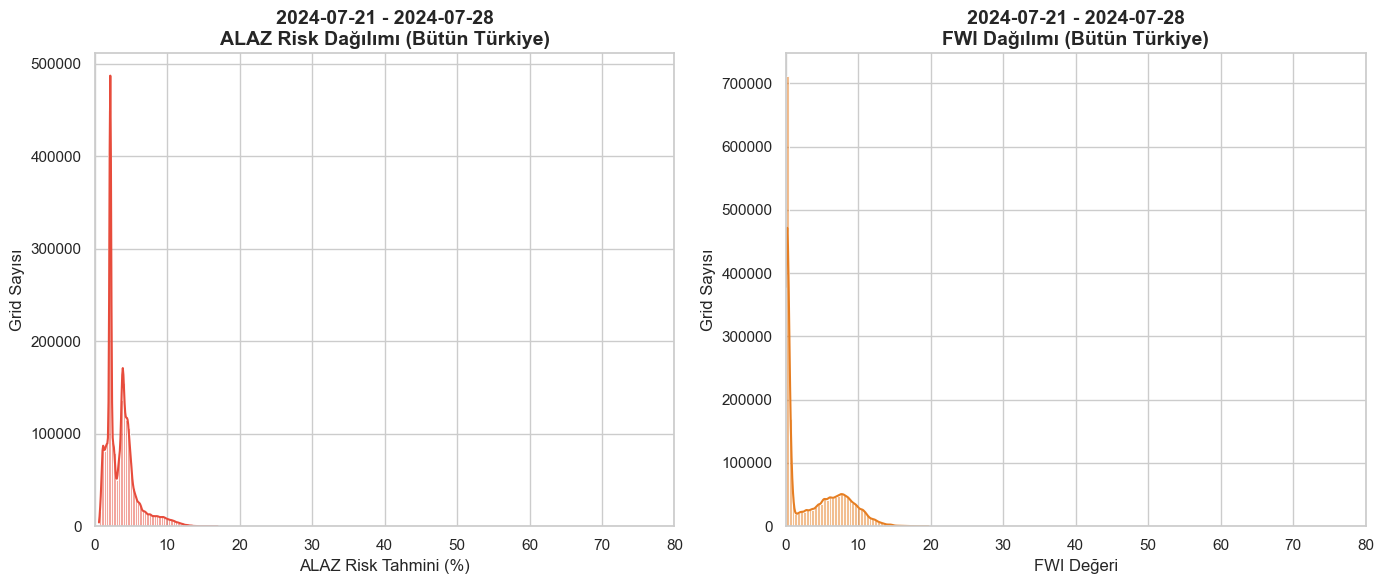


🔥 EN RİSKLİ 10 BÖLGE (Hocaya Gösterilecek Noktalar):


,GRID_ID,Bolge,FWI_Final,risk_percent,Tarih
1617670,883f663711fffff,MED,9.735841,16.949246,2024-07-27
1719755,882d039801fffff,BLK,0.823433,16.798035,2024-07-28
379162,882d3551c3fffff,BLK,9.405698,16.775913,2024-07-22
379147,882d355199fffff,BLK,9.405698,16.480589,2024-07-22
379167,882d3551d1fffff,BLK,9.405698,16.480589,2024-07-22
315181,882d04c8bdfffff,BLK,6.226546,16.090333,2024-07-22
1716120,882d03124dfffff,BLK,0.739749,15.994308,2024-07-28
379173,882d3551ddfffff,BLK,9.405698,15.850534,2024-07-22
379161,882d3551c1fffff,BLK,9.405698,15.683960,2024-07-22
1719756,882d039803fffff,BLK,0.823433,15.638140,2024-07-28


In [2]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Görsel ayarları
sns.set_theme(style="whitegrid")

# Backend'i yola ekliyoruz ki senin uygulamanın motorunu (ALAZEngine) kullanabilelim
backend_path = r"c:\Users\Yusuf\Desktop\Tez-bolgesel\Web_App\backend"
if backend_path not in sys.path:
    sys.path.append(backend_path)

from inference import ALAZEngine

print("🚀 ALAZ Motoru başlatılıyor (Statik veriler yükleniyor)...")
engine = ALAZEngine(base_dir=r"c:\Users\Yusuf\Desktop\Tez-bolgesel")

start_date = "2024-07-21"
end_date = "2024-07-28"
dates = pd.date_range(start_date, end_date)

all_results = []

for d in dates:
    date_str = d.strftime('%Y-%m-%d')
    print(f"📡 {date_str} için hava durumu verileri çekiliyor ve ALAZ çalıştırılıyor...")
    
    # 1. NetCDF üzerinden o günün ham FWI ve iklim verilerini çek
    df_fwi = engine.nc_engine.extract_climate_and_fwi(date_str)
    
    # 2. Makine Öğrenmesi özelliklerini üret
    df_ml = engine.compute_ml_features(df_fwi, date_str)
    df_ml['risk_percent'] = 0.0
    
    # 3. Bölgeler için modeli koştur
    for bolge in ['MED', 'CON', 'BLK']:
        mask = df_ml['Bolge'] == bolge
        if mask.sum() == 0: continue
        
        model = engine.models[bolge]
        feats = engine.features[bolge]
        
        X = df_ml.loc[mask].copy()
        for f in feats:
            if f not in X.columns:
                X[f] = 0
        X = X[feats]
        
        df_ml.loc[mask, 'risk_percent'] = model.predict_proba(X)[:, 1] * 100
        
    # Bize lazım olan kısımları alıp listeye ekle
    # Sadece verisi olan (kara) gridleri almak için dropna yapalım
    df_subset = df_ml[['GRID_ID', 'Bolge', 'FWI_Final', 'risk_percent']].copy()
    df_subset['Tarih'] = date_str
    all_results.append(df_subset.dropna())

# Tüm günleri tek bir dev tablo yap
final_df = pd.concat(all_results, ignore_index=True)

print("\n✅ === SİMÜLASYON TAMAMLANDI ===")
print(f"Toplam incelenen grid-gün sayısı: {len(final_df)}")

# İstatistikleri tablo olarak yazdır
stats_df = pd.DataFrame({
    'ALAZ Risk (%)': final_df['risk_percent'].describe(percentiles=[0.5, 0.75, 0.85, 0.90, 0.95, 0.99]),
    'FWI Skoru': final_df['FWI_Final'].describe(percentiles=[0.5, 0.75, 0.85, 0.90, 0.95, 0.99])
}).round(2)

print("\n📋 21-28 TEMMUZ RİSK VE FWI DAĞILIMI (TÜM HARİTA)")
display(stats_df)

# Görselleştirme
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(final_df['risk_percent'], bins=50, color='#e74c3c', kde=True)
plt.title(f"{start_date} - {end_date}\nALAZ Risk Dağılımı (Bütün Türkiye)", fontsize=14, fontweight='bold')
plt.xlabel("ALAZ Risk Tahmini (%)")
plt.ylabel("Grid Sayısı")
plt.xlim(0, 80)

plt.subplot(1, 2, 2)
sns.histplot(final_df['FWI_Final'], bins=50, color='#e67e22', kde=True)
plt.title(f"{start_date} - {end_date}\nFWI Dağılımı (Bütün Türkiye)", fontsize=14, fontweight='bold')
plt.xlabel("FWI Değeri")
plt.ylabel("Grid Sayısı")
plt.xlim(0, 80)

plt.tight_layout()
plt.show()

print("\n🔥 EN RİSKLİ 10 BÖLGE (Hocaya Gösterilecek Noktalar):")
display(final_df.sort_values(by='risk_percent', ascending=False).head(10))